<h1> Radar Imaging Part 1</h1>
In this lab assignment, we will implement a 3D mmWave Radar Imaging system. Before
starting the lab, please review the class lectures. We provide the data to work
on.

This lab consists of several tasks. You are provided with some skeleton code for
loading the lab data in the correct format and plotting the output radar heatmaps/point
clouds for each task. The Jupyter notebook holds all of the relevant code blocks you will need to implement.

You must submit the Jupyter Notebook with the code and a PDF for the figures requested.

The format of the mmWave radar data is as follows. The radar used has 1 transmitter and 4 receivers which is laid out linearly on the x axis (the transmitters are placed directly to the side of the receivers, but for the purposes of this lab, we will ignore the transmitters location).
The radar data is collected by a 2D Synthetic Aperture Radar (SAR). The radar was placed on a linear scanning platform with moved vertically to 369 locations which were one quarter wavelenth apart and then moving horizontally to 80 discrete locations which were one wavelength apart. This gives a size of 80 by 369 at one-wavelength by quarter-wavelength (i.e. the total size of the scanning area is 0.38 cm by 0.35 cm at 77 GHz). The 2D antenna array
is placed on the X-Z plane, as shown in Fig. 1. <i> NOTE: This is different than the coordinate system introduced in the lecture. So you will have to adjust the beamforming angles accordingly.</i> 

The mmWave radar has a center frequency of
77 GHz and it transmits Frequency Modulated Continuous Wave (FMCW) radar waveform
with 3.5991 GHz bandwidth (sweeps from 77 GHz with a slope of 70.295 MHz/us). 
The FMCW beat frequency signal (output of mixing reflected chirp with reference
chirp) is sampled 512 times at a sampling rate of 10,000 ksps. We have massaged the data a bit, so the mmWave radar data output from the radar is a 3D matrix
with a of size 320 $\times$ 369 $\times$ 512. The first dimension is
horizontal locations (x axis) of the antennas (in this case 80 steps by 4 receivers = 320), the second dimension is the vertical locations(z axis) of the
antennas (369 in this case), and the third dimension is the number of time domain data samples we have (512). 
The layout of this pattern can also be found in Fig. 1. We provide the x,z-position the receivers as well as the location of the radar at each instant. 

Note on coding: You can change input/outputs from functions as you please as well as any plotting code, however, the final plotted image is what we will look at for grading. 
Additionally, we recommend that you 
comment your code to make it easier for partial credit to be awarded.

The data and details are available in the folder `data/`.
A subset of what the results might look like are shown in example_outputs.pdf, however, this is of different data and not necessarily all of the plots we expect. These examples are simply to show an example of what you might expect. 

This lab is broken into two parts:
1. 2D Imaging using 1D Antenna Array
2. 3D Imaging using 2D Antenna Array

![title](imgs/coordinate_system.png)

<h3>2D Imaging using 1D Antenna Array </h3>

In this task, our goal is to implement Algorithm 1 (beamforming) taught in class for a
1D antenna array. You will generate the 2D radar heatmap (bird eye view) by estimating the reflected signal
power from azimuth angles $\phi$ between 60 and 130 degrees with a resolution of 1. The definition for $\phi$ can be found in Fig. 1 shown in task1.
The code for this task should be written in the function *beamform_1d*. We provide you the
code to load the radar data in the right format and to plot the 2D horizontal plane heatmap
in this file. 

As results, you need to include the following in your turned in file:
1. Include the 2D heatmap you generate for **all three sets of data given**. For the 1D antenna array signal, you can take
the beat signals from any one horizontal row of antenna elements in the 2D grid (aka select one z index to use).

Implement your 1D Beamforming algortihm.

In [1]:
# TODO: Implement the function
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta 
def beamform_1d(beat_freq_data, phi_s, phi_e, phi_res, locs, radar_params):
    """
    Performs 1D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.

    Paramters:
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num TX * num RX, num ADC samples)
    - phi_s: first angle that you want to start computing 
    - phi_e: last angle that you want to compute 
    - phi_res: resolution of the angles you want to compute
    - locs: antenna locations
    - radar_parms: radar_params if needed 
        'sample_rate', 'num_samples', 'slope', 'lm', 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples'

    Returns:
    - sph_pwr: beamformed result (size: num_phi x num adc samples)
    - phi: the array of the angles computed
    """
    
    phi_deg = np.arange(phi_s, phi_e + phi_res, phi_res)
    phi_rad = np.deg2rad(phi_deg)
    num_phi = len(phi_deg)

    ant_x = locs[:, 0]
    wavelength = radar_params["lm"]
    num_range = beat_freq_data.shape[1]
    
    sph_pwr = np.zeros((num_phi, num_range), dtype=complex)

    for idx, ang in enumerate(phi_rad):
        steering = np.exp(-1j * (2 * np.pi / wavelength) * ant_x * np.cos(ang))
        sph_pwr[idx, :] = steering.dot(beat_freq_data)

    return sph_pwr, phi_rad

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import utils

We will load the data.

In [13]:
# TODO: download data and set to path to the data 
data_path = r"data/data_003_.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp * num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Here we define the antenna spacing. Since we are dealing with a 1D array, you just need the x-dimension locations of each antenna given in ant_pos.

In [14]:
ant_pos = utils.get_ant_pos_1d(radar_params['num_x_stp'], radar_params['num_rx'])

Process the raw data so we have the beat frequency (see lectures). Additionally, you only need to run this on *one* vertical (z) location. So pick any index.

In [ ]:
# TODO: Process Raw Data for Beamforming 

z_index = 0
raw_1d = raw_data[:, z_index, :]    # shape (num_x_stp * num_rx, adc_samples)
adc_samples = radar_params['adc_samples']

beat_freq = np.fft.fft(raw_1d, axis=-1)

Define the angles to calculate and run your algorthim below.

In [16]:
# define the azimuth angles (horizontal FOV) that we want to look at 
phi_s, phi_e = 60, 130
phi_res = 1
# Run your algorithm here
bf_output, phi_deg = beamform_1d(beat_freq, phi_s,phi_e,phi_res,ant_pos,radar_params)

Here is code for plotting the heatmap. If you are not seeing colorful 2D heatmaps as expected, tune the variables *vmin* and *vmax* as those determine the colormap.

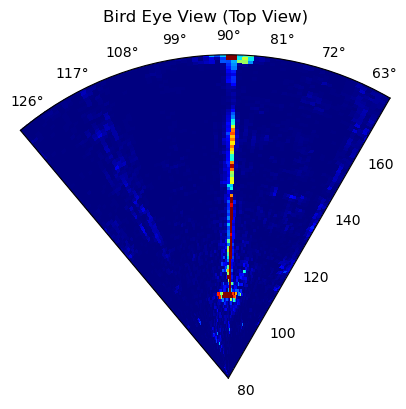

In [ ]:
# Plot the output from 1D Beamforming (You can change this as you see fit)
fig = plt.figure()
r_idxs = np.arange(80,180)  # crop range bins
to_plot = abs(bf_output[:,r_idxs])**2 # take power of the output
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))  # normalize

vmin = 0
vmax = 0.1

ax0 = fig.add_subplot(111, projection='polar')
utils.plot_2d_heatmap(ax0, to_plot, phi_deg, r_idxs, vmin=vmin, vmax=vmax)
ax0.title.set_text('Bird Eye View (Top View)')
ax0.set_aspect('equal','box')